# Trening Faster R-CNN ResNet50-FPN v2 - SoccerNet

Trening modelu Faster R-CNN do detekcji obiektow na obrazach z meczu pilki noznej.
Srodowisko docelowe: Google Colab z GPU (T4/L4).

Klasy (1-indexed, 0 = background):
- 1: ball
- 2: player
- 3: referee

Kluczowe decyzje treningowe:
- **Bez resize do kwadratu** — obrazy ladowane w oryginalnej rozdzielczosci,
  FPN sam skaluje (min_size/max_size) z zachowaniem proporcji
- **Augmentacja** — RandomHorizontalFlip + ColorJitter (jasnosc/kontrast/saturacja)
- **Warmup + CosineAnnealing** — stabilny start, plynne wygas LR
- **Mixed Precision (AMP)** — 2x szybszy trening, mniejsze zuzycie VRAM
- **Gradient accumulation** — efektywny batch 16 przy fizycznym batch 4

## 1. Konfiguracja srodowiska

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, glob, time, random
import torch
import torchvision
import numpy as np

gpu_name = torch.cuda.get_device_name(0)
gpu_mem  = torch.cuda.get_device_properties(0).total_memory / (1024**3)
print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
print(f"PyTorch: {torch.__version__}, CUDA: {torch.version.cuda}")
print(f"Torchvision: {torchvision.__version__}")

Mounted at /content/drive
GPU: NVIDIA A100-SXM4-80GB (79.3 GB)
PyTorch: 2.11.0+cu128, CUDA: 12.8
Torchvision: 0.26.0+cu128


## 2. Sciezki i hiperparametry

In [2]:
ZIP_PATH       = "/content/drive/MyDrive/CvFootballTracker_Data/Detection/yoloformat.zip"
LOCAL_DATA_DIR = "/content/yoloformat"
PROJECT_DIR    = "/content/drive/MyDrive/CvFootballTracker_Data/results"
RUN_NAME       = "frcnn_soccernet_v2"

# ---- Architektura ----
NUM_CLASSES  = 4       # background + ball + player + referee
IMG_MIN_SIZE = 800     # FPN: krotszy bok skalowany do tego
IMG_MAX_SIZE = 1333    # FPN: dluzszy bok ograniczony do tego
# Dla 1920x1080 daje ~1333x750 (aspect ratio zachowany, ~1M px jak YOLO 960x960)

# ---- Trening ----
BATCH_SIZE   = 8
ACCUM_STEPS  = 4       # gradient accumulation -> efektywny batch = 8*4 = 32
NUM_EPOCHS   = 50
PATIENCE     = 8      # early stopping

# ---- Optimizer (SGD + momentum, standard dla Faster R-CNN) ----
LR           = 0.005   # LR bazowy (po warmup)
MOMENTUM     = 0.9
WEIGHT_DECAY = 0.0005
BACKBONE_LR_FACTOR = 0.1   # backbone uczy sie 10x wolniej niz glowica (ochrona COCO features)

# ---- Scheduler ----
WARMUP_EPOCHS = 1      # liniowy warmup od LR/10 do LR
LR_MIN        = 1e-6   # minimalne LR (koniec cosine)

# ---- Inne ----
NUM_WORKERS = 4
SEED        = 17
USE_AMP     = True     # Mixed Precision - wylacz jesli problemy numeryczne

CLASS_NAMES = {0: 'background', 1: 'ball', 2: 'player', 3: 'referee'}

print(f"Efektywny batch size: {BATCH_SIZE * ACCUM_STEPS}")
print(f"Obraz: min_size={IMG_MIN_SIZE}, max_size={IMG_MAX_SIZE}")
print(f"AMP: {USE_AMP}")

Efektywny batch size: 32
Obraz: min_size=800, max_size=1333
AMP: True


## 3. Ekstrakcja danych z Google Drive

In [3]:
if not os.path.exists(LOCAL_DATA_DIR):
    print("Rozpakowywanie archiwum...")
    shutil.unpack_archive(ZIP_PATH, extract_dir="/content/")
    print("Zakonczono.")
else:
    print("Dane juz dostepne na dysku lokalnym.")

n_train = len(glob.glob(f"{LOCAL_DATA_DIR}/train/*/images/*.jpg"))
n_valid = len(glob.glob(f"{LOCAL_DATA_DIR}/valid/*/images/*.jpg"))
print(f"Liczba obrazow - train: {n_train}, valid: {n_valid}")

Rozpakowywanie archiwum...
Zakonczono.
Liczba obrazow - train: 11500, valid: 8250


## 4. Dataset i DataLoader

- Obrazy ladowane w **oryginalnej rozdzielczosci** (brak resize do kwadratu!)
- Boxy konwertowane z YOLO norm (cx cy w h) na piksele (x1 y1 x2 y2)
- Augmentacja treningowa: **RandomHorizontalFlip** + **ColorJitter**
- FPN sam zajmie sie skalowaniem i paddingiem wewnetrznie

In [4]:
import cv2
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF


class YOLOFormatDataset(Dataset):
    """
    Wczytuje YOLO-format i konwertuje do torchvision Faster R-CNN.
    Obrazy w oryginalnej rozdzielczosci — FPN skaluje wewnetrznie.
    """

    def __init__(self, base_dir, augment=False):
        self.augment = augment
        self.samples = []

        base = Path(base_dir)
        for clip_dir in sorted(base.iterdir()):
            images_dir = clip_dir / "images"
            labels_dir = clip_dir / "labels"
            if not images_dir.is_dir():
                continue
            for img_path in sorted(images_dir.glob("*.jpg")):
                lbl_path = labels_dir / img_path.with_suffix(".txt").name
                self.samples.append((img_path, lbl_path))

        print(f"  Dataset: {len(self.samples)} obrazow z {base_dir} (augment={augment})")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, lbl_path = self.samples[idx]

        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h_orig, w_orig = image.shape[:2]

        # Parsowanie YOLO labels -> boxy w pikselach
        boxes = []
        labels = []

        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_yolo = int(parts[0])  # 0=ball, 1=player, 2=referee
                    cx, cy, bw, bh = map(float, parts[1:5])

                    x1 = max(0.0, (cx - bw / 2) * w_orig)
                    y1 = max(0.0, (cy - bh / 2) * h_orig)
                    x2 = min(float(w_orig), (cx + bw / 2) * w_orig)
                    y2 = min(float(h_orig), (cy + bh / 2) * h_orig)

                    if x2 > x1 + 1 and y2 > y1 + 1:
                        boxes.append([x1, y1, x2, y2])
                        labels.append(cls_yolo + 1)  # +1 bo 0=background w FRCNN

        if boxes:
            boxes_t = torch.tensor(boxes, dtype=torch.float32)
            labels_t = torch.tensor(labels, dtype=torch.int64)
        else:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros(0, dtype=torch.int64)

        # Augmentacja
        if self.augment:
            # 1. Random Horizontal Flip (p=0.5)
            if random.random() < 0.5:
                image = image[:, ::-1, :].copy()  # flip W
                if len(boxes_t) > 0:
                    boxes_t[:, [0, 2]] = w_orig - boxes_t[:, [2, 0]]  # flip x1<->x2

            # 2. ColorJitter (jasnosc, kontrast, saturacja)
            image_pil = TF.to_pil_image(image)
            image_pil = torchvision.transforms.ColorJitter(
                brightness=0.3, contrast=0.3, saturation=0.3, hue=0.02
            )(image_pil)
            image = np.array(image_pil)

        # Konwersja do tensora [3, H, W] float32 [0,1]
        image_t = TF.to_tensor(image)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
        }

        return image_t, target


def collate_fn(batch):
    return tuple(zip(*batch))


# Reproducibility
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("Ladowanie danych...")
train_dataset = YOLOFormatDataset(f"{LOCAL_DATA_DIR}/train", augment=True)
valid_dataset = YOLOFormatDataset(f"{LOCAL_DATA_DIR}/valid", augment=False)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True,
    drop_last=True,  # stabilnosc gradient accumulation
)
valid_loader = DataLoader(
    valid_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"Batchy: train={len(train_loader)}, valid={len(valid_loader)}")
print(f"Iteracji/epoka: {len(train_loader)}, aktualizacji wag/epoka: {len(train_loader)//ACCUM_STEPS}")

Ladowanie danych...
  Dataset: 11500 obrazow z /content/yoloformat/train (augment=True)
  Dataset: 8250 obrazow z /content/yoloformat/valid (augment=False)
Batchy: train=1437, valid=1032
Iteracji/epoka: 1437, aktualizacji wag/epoka: 359


## 5. Inicjalizacja modelu

- Faster R-CNN ResNet50-FPN v2 z COCO pretrained
- Nowa glowica (4 klasy)
- **min_size/max_size** ustawione zamiast recznego resize
- SGD + **LinearLR warmup** (1 epoka) + **CosineAnnealingLR**
- Resume z checkpointu na Drive

In [5]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Sciezki checkpointow na Drive
save_dir = f"{PROJECT_DIR}/{RUN_NAME}"
os.makedirs(save_dir, exist_ok=True)
best_path = f"{save_dir}/best.pt"
last_path = f"{save_dir}/last.pt"


def create_model(num_classes, min_size=IMG_MIN_SIZE, max_size=IMG_MAX_SIZE):
    model = fasterrcnn_resnet50_fpn_v2(
        weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT,
        min_size=min_size,
        max_size=max_size,
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


device = torch.device("cuda")
model = create_model(NUM_CLASSES)
model.to(device)

# ---- Optimizer ----
# params = [p for p in model.parameters() if p.requires_grad]
# optimizer = torch.optim.SGD(params, lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

backbone_params = [p for n, p in model.named_parameters()
                   if "backbone" in n and p.requires_grad]
head_params     = [p for n, p in model.named_parameters()
                   if "backbone" not in n and p.requires_grad]

optimizer = torch.optim.SGD([
    {"params": backbone_params, "lr": LR * BACKBONE_LR_FACTOR},  # 0.0005
    {"params": head_params,     "lr": LR},                        # 0.005
], momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

print(f"LR backbone: {LR * BACKBONE_LR_FACTOR:.5f}, LR glowica: {LR:.5f}")

# ---- Scheduler: warmup (linear 1 epoka) + cosine annealing ----
steps_per_epoch = len(train_loader) // ACCUM_STEPS  # aktualizacje wag / epoka
warmup_steps = steps_per_epoch * WARMUP_EPOCHS
cosine_steps = steps_per_epoch * (NUM_EPOCHS - WARMUP_EPOCHS)

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, total_iters=warmup_steps
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cosine_steps, eta_min=LR_MIN
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_steps],
)

# ---- AMP ----
scaler = torch.amp.GradScaler(enabled=USE_AMP)

start_epoch = 0
best_val_loss = float("inf")
global_step = 0  # licznik aktualizacji wag (dla scheduler)

# ---- Resume z checkpointu ----
if os.path.exists(last_path):
    ckpt = torch.load(last_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    scaler.load_state_dict(ckpt["scaler_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    best_val_loss = ckpt.get("best_val_loss", float("inf"))
    global_step = ckpt.get("global_step", 0)
    print(f"Wznowienie z epoki {start_epoch} (best_val_loss={best_val_loss:.4f}, step={global_step})")
else:
    print("Start od wag COCO pretrained")

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model na: {device}")
print(f"Parametry trenowalnych: {n_params/1e6:.1f}M")
print(f"Scheduler: warmup {WARMUP_EPOCHS} epok (LR {LR*0.1:.4f} -> {LR}) + cosine -> {LR_MIN}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 182MB/s]


LR backbone: 0.00050, LR glowica: 0.00500
Start od wag COCO pretrained
Model na: cuda
Parametry trenowalnych: 43.0M
Scheduler: warmup 1 epok (LR 0.0005 -> 0.005) + cosine -> 1e-06


## 6. Trening

- **Gradient accumulation** (efektywny batch 16)
- **Mixed precision** (AMP) — szybciej, mniej VRAM
- **Gradient clipping** (stabilnosc)
- Walidacja po kazdej epoce, zapis na Drive, early stopping

In [6]:
def train_one_epoch(model, dataloader, optimizer, scheduler, scaler, device, epoch, accum_steps):
    model.train()
    total_loss = 0.0
    n_batches = 0
    global global_step

    optimizer.zero_grad()

    for batch_idx, (images, targets) in enumerate(dataloader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Filtruj puste targety
        valid_pairs = [(img, tgt) for img, tgt in zip(images, targets) if tgt["boxes"].shape[0] > 0]
        if not valid_pairs:
            continue
        images, targets = zip(*valid_pairs)
        images, targets = list(images), list(targets)

        # Forward z AMP
        with torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            losses = losses / accum_steps  # normalizacja dla accumulation

        scaler.scale(losses).backward()

        # Aktualizacja wag co accum_steps batchy
        if (batch_idx + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()
            global_step += 1

        total_loss += losses.item() * accum_steps  # przywroc oryginalna skale
        n_batches += 1

        if (batch_idx + 1) % 200 == 0:
            lr_now = optimizer.param_groups[0]["lr"]
            print(f"  Epoch {epoch} | Batch {batch_idx+1}/{len(dataloader)} | "
                  f"Loss: {losses.item()*accum_steps:.4f} | LR: {lr_now:.6f}")

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def validate(model, dataloader, device):
    model.train()  # FRCNN zwraca loss tylko w train()
    total_loss = 0.0
    n_batches = 0

    for images, targets in dataloader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        valid_pairs = [(img, tgt) for img, tgt in zip(images, targets) if tgt["boxes"].shape[0] > 0]
        if not valid_pairs:
            continue
        images, targets = zip(*valid_pairs)
        images, targets = list(images), list(targets)

        with torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        total_loss += losses.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)


def save_checkpoint(model, optimizer, scheduler, scaler, epoch, best_val_loss, global_step, path):
    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "epoch": epoch,
        "best_val_loss": best_val_loss,
        "global_step": global_step,
    }, path)


# ---- Petla treningowa ----
print(f"Start treningu: epoki {start_epoch+1}-{NUM_EPOCHS}")
print(f"Batch: {BATCH_SIZE} x {ACCUM_STEPS} accum = efektywny {BATCH_SIZE*ACCUM_STEPS}")
print(f"AMP: {USE_AMP}")
print(f"Wyniki: {save_dir}")
print()

epochs_no_improve = 0
history = []

for epoch in range(start_epoch, NUM_EPOCHS):
    t0 = time.time()

    train_loss = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler, device, epoch + 1, ACCUM_STEPS
    )
    val_loss = validate(model, valid_loader, device)

    elapsed = time.time() - t0
    lr_now = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
        f"train: {train_loss:.4f} | val: {val_loss:.4f} | "
        f"lr: {lr_now:.6f} | {elapsed:.0f}s"
    )

    history.append({"epoch": epoch+1, "train_loss": train_loss, "val_loss": val_loss, "lr": lr_now})

    # Zapis last.pt (zawsze)
    save_checkpoint(model, optimizer, scheduler, scaler, epoch, best_val_loss, global_step, last_path)

    # Zapis best.pt
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        save_checkpoint(model, optimizer, scheduler, scaler, epoch, best_val_loss, global_step, best_path)
        print(f"  -> Nowy best (val_loss={val_loss:.4f})")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping po {epoch+1} epokach (brak poprawy przez {PATIENCE} epok)")
        break

print(f"\nTrening zakonczony. Best val_loss: {best_val_loss:.4f}")
print(f"Checkpointy: {save_dir}")

Start treningu: epoki 1-50
Batch: 8 x 4 accum = efektywny 32
AMP: True
Wyniki: /content/drive/MyDrive/CvFootballTracker_Data/results/frcnn_soccernet_v2

  Epoch 1 | Batch 200/1437 | Loss: 1.1154 | LR: 0.000113
  Epoch 1 | Batch 400/1437 | Loss: 0.8270 | LR: 0.000175
  Epoch 1 | Batch 600/1437 | Loss: 0.8631 | LR: 0.000238
  Epoch 1 | Batch 800/1437 | Loss: 0.6263 | LR: 0.000301
  Epoch 1 | Batch 1000/1437 | Loss: 0.6991 | LR: 0.000363
  Epoch 1 | Batch 1200/1437 | Loss: 0.7492 | LR: 0.000426
  Epoch 1 | Batch 1400/1437 | Loss: 0.7156 | LR: 0.000489
Epoch   1/50 | train: 0.9433 | val: 0.6860 | lr: 0.000500 | 919s
  -> Nowy best (val_loss=0.6860)
  Epoch 2 | Batch 200/1437 | Loss: 0.7023 | LR: 0.000500
  Epoch 2 | Batch 400/1437 | Loss: 0.6603 | LR: 0.000500
  Epoch 2 | Batch 600/1437 | Loss: 0.5542 | LR: 0.000500
  Epoch 2 | Batch 800/1437 | Loss: 0.5095 | LR: 0.000500
  Epoch 2 | Batch 1000/1437 | Loss: 0.6163 | LR: 0.000500
  Epoch 2 | Batch 1200/1437 | Loss: 0.5508 | LR: 0.000500
  E

## 7. Wykres loss

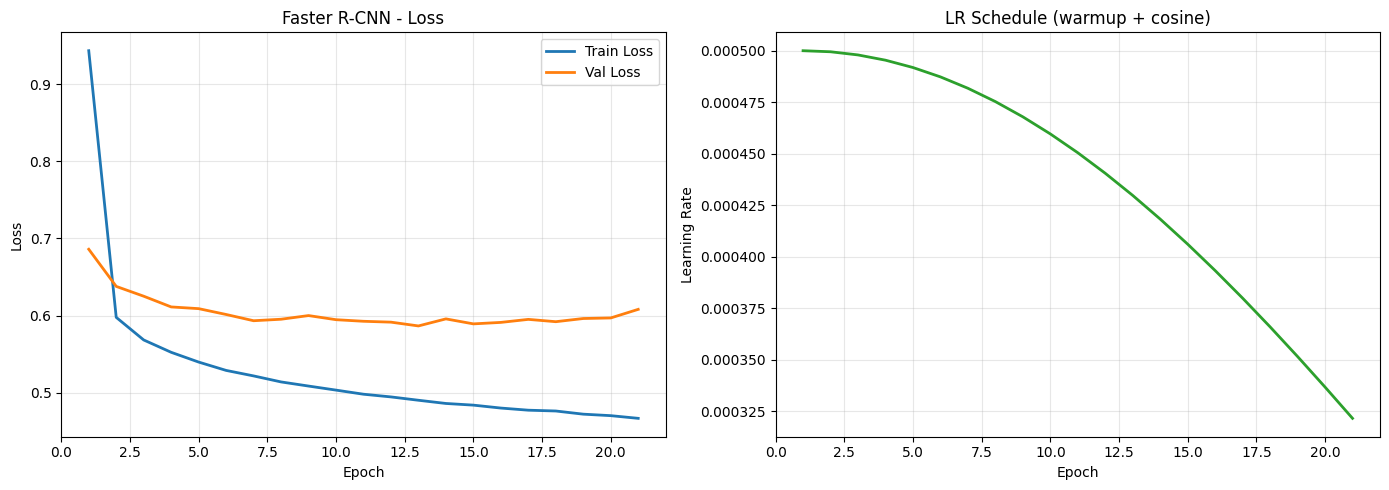

Wykres zapisany: /content/drive/MyDrive/CvFootballTracker_Data/results/frcnn_soccernet_v2/loss_plot.png


In [7]:
import matplotlib.pyplot as plt

if history:
    epochs_list = [h["epoch"] for h in history]
    train_losses = [h["train_loss"] for h in history]
    val_losses = [h["val_loss"] for h in history]
    lrs = [h["lr"] for h in history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs_list, train_losses, label="Train Loss", linewidth=2)
    ax1.plot(epochs_list, val_losses, label="Val Loss", linewidth=2)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Faster R-CNN - Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs_list, lrs, linewidth=2, color="tab:green")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Learning Rate")
    ax2.set_title("LR Schedule (warmup + cosine)")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{save_dir}/loss_plot.png", dpi=150)
    plt.show()
    print(f"Wykres zapisany: {save_dir}/loss_plot.png")
else:
    print("Brak danych do wykresu (trening nie uruchomiony w tej sesji)")

## 8. Ewaluacja (mAP) na zbiorze walidacyjnym

COCO-style mAP: AP@0.5 i AP@0.5:0.95 per klasa.

In [8]:
from torchvision.ops import box_iou

# Zaladuj best model
eval_model = create_model(NUM_CLASSES)
ckpt = torch.load(best_path, map_location=device)
eval_model.load_state_dict(ckpt["model_state_dict"])
eval_model.to(device)
eval_model.eval()

print(f"Zaladowano best.pt (epoch {ckpt['epoch']+1}, val_loss={ckpt['best_val_loss']:.4f})")
print("Ewaluacja na zbiorze walidacyjnym...\n")


def compute_ap(recalls, precisions):
    """AP - 101-point interpolation (COCO-style)."""
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([1.0], precisions, [0.0]))
    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])
    recall_points = np.linspace(0, 1, 101)
    precision_at_recall = np.zeros(101)
    for i, r in enumerate(recall_points):
        idx = np.where(mrec >= r)[0]
        if len(idx) > 0:
            precision_at_recall[i] = mpre[idx[0]]
    return precision_at_recall.mean()


def evaluate_class(all_preds, all_gts, class_id, iou_threshold=0.5):
    """AP dla jednej klasy przy danym IoU threshold."""
    preds = []
    n_gt = 0
    gt_matched = {}

    for img_idx, (pred, gt) in enumerate(zip(all_preds, all_gts)):
        gt_mask = gt["labels"].cpu().numpy() == class_id
        gt_boxes = gt["boxes"].cpu().numpy()[gt_mask]
        n_gt += len(gt_boxes)
        gt_matched[img_idx] = np.zeros(len(gt_boxes), dtype=bool)

        pred_mask = pred["labels"].cpu().numpy() == class_id
        pred_boxes = pred["boxes"].cpu().numpy()[pred_mask]
        pred_scores = pred["scores"].cpu().numpy()[pred_mask]

        for j in range(len(pred_boxes)):
            preds.append((img_idx, pred_scores[j], pred_boxes[j]))

    if n_gt == 0:
        return 0.0

    preds.sort(key=lambda x: x[1], reverse=True)
    tp = np.zeros(len(preds))
    fp = np.zeros(len(preds))

    for i, (img_idx, score, pred_box) in enumerate(preds):
        gt = all_gts[img_idx]
        gt_mask = gt["labels"].cpu().numpy() == class_id
        gt_boxes = gt["boxes"].cpu().numpy()[gt_mask]

        if len(gt_boxes) == 0:
            fp[i] = 1
            continue

        ious = box_iou(
            torch.from_numpy(pred_box).unsqueeze(0).float(),
            torch.from_numpy(gt_boxes).float()
        ).numpy()[0]

        best_iou_idx = ious.argmax()
        best_iou = ious[best_iou_idx]

        if best_iou >= iou_threshold and not gt_matched[img_idx][best_iou_idx]:
            tp[i] = 1
            gt_matched[img_idx][best_iou_idx] = True
        else:
            fp[i] = 1

    cum_tp = np.cumsum(tp)
    cum_fp = np.cumsum(fp)
    recalls = cum_tp / n_gt
    precisions = cum_tp / (cum_tp + cum_fp)

    return compute_ap(recalls, precisions)


# Zbieranie predykcji
all_preds = []
all_gts = []

with torch.no_grad():
    for batch_idx, (images, targets) in enumerate(valid_loader):
        images = [img.to(device) for img in images]
        with torch.amp.autocast(device_type="cuda", enabled=USE_AMP):
            preds = eval_model(images)
        all_preds.extend([{k: v.cpu() for k, v in p.items()} for p in preds])
        all_gts.extend(targets)
        if (batch_idx + 1) % 50 == 0:
            print(f"  {batch_idx+1}/{len(valid_loader)}")

# Raport
print(f"\n{'='*60}")
print(f"Ewaluacja najlepszego modelu (best.pt)")
print(f"{'='*60}")

iou_thresholds_50_95 = np.arange(0.5, 1.0, 0.05)
class_names_eval = {1: 'ball', 2: 'player', 3: 'referee'}

maps_50 = []
maps_50_95 = []

for cls_id, cls_name in class_names_eval.items():
    ap50 = evaluate_class(all_preds, all_gts, cls_id, iou_threshold=0.5)
    aps = [evaluate_class(all_preds, all_gts, cls_id, iou_threshold=t) for t in iou_thresholds_50_95]
    ap50_95 = np.mean(aps)

    maps_50.append(ap50)
    maps_50_95.append(ap50_95)

    print(f"  {cls_name:10s}  AP@0.5: {ap50:.4f}  |  AP@0.5:0.95: {ap50_95:.4f}")

print(f"\n  {'mAP':10s}  AP@0.5: {np.mean(maps_50):.4f}  |  AP@0.5:0.95: {np.mean(maps_50_95):.4f}")
print(f"\nSciezka do modelu: {best_path}")

Zaladowano best.pt (epoch 13, val_loss=0.5866)
Ewaluacja na zbiorze walidacyjnym...

  50/1032
  100/1032
  150/1032
  200/1032
  250/1032
  300/1032
  350/1032
  400/1032
  450/1032
  500/1032
  550/1032
  600/1032
  650/1032
  700/1032
  750/1032
  800/1032
  850/1032
  900/1032
  950/1032
  1000/1032

Ewaluacja najlepszego modelu (best.pt)
  ball        AP@0.5: 0.4738  |  AP@0.5:0.95: 0.1765
  player      AP@0.5: 0.9472  |  AP@0.5:0.95: 0.5834
  referee     AP@0.5: 0.9351  |  AP@0.5:0.95: 0.5416

  mAP         AP@0.5: 0.7854  |  AP@0.5:0.95: 0.4339

Sciezka do modelu: /content/drive/MyDrive/CvFootballTracker_Data/results/frcnn_soccernet_v2/best.pt


## 9. Eksport wag do pipeline

Eksportuje sam state_dict (bez optimizer/scheduler) - kompatybilny z `FasterRCNNDetector`.

In [9]:
export_path = f"{save_dir}/trained_fasterrcnn_resnet50.pt"

ckpt = torch.load(best_path, map_location="cpu")
torch.save(ckpt["model_state_dict"], export_path)

size_mb = os.path.getsize(export_path) / 1e6
print(f"Wyeksportowano: {export_path} ({size_mb:.1f} MB)")
print(f"\nSkopiuj do projektu jako:")
print(f"  models/faster_rcnn/trained_fasterrcnn_resnet50.pt")

Wyeksportowano: /content/drive/MyDrive/CvFootballTracker_Data/results/frcnn_soccernet_v2/trained_fasterrcnn_resnet50.pt (173.4 MB)

Skopiuj do projektu jako:
  models/faster_rcnn/trained_fasterrcnn_resnet50.pt


---
## Komorka opcjonalna - sprzatanie

In [ ]:
target = f"{PROJECT_DIR}/{RUN_NAME}"
if os.path.exists(target):
    confirm = input(f"Usunac {target}? (tak/nie): ")
    if confirm.lower() == "tak":
        shutil.rmtree(target)
        print("Usunieto.")
    else:
        print("Anulowano.")
else:
    print("Folder nie istnieje, nic do usuniecia.")